## WormLib 
## Example 1 - single cell segmentation with spot detection and spatial analysis

In [1]:
# Check the Python environment
import sys, os
from pathlib import Path as PathlibPath
print("Conda env:", os.environ.get("CONDA_DEFAULT_ENV"))

# WormLib isn't published to PyPi yet, manually resolve src/directory and import WormLib functions
current_dir = PathlibPath().resolve()
script_dir = PathlibPath(".").resolve()
search_roots = [current_dir, *current_dir.parents, script_dir, *script_dir.parents]
src_dir = next((root / 'src' for root in search_roots if (root / 'src').is_dir()), None)

if src_dir is None:
    raise RuntimeError("Could not find the WormLib src directory.")

sys.path.insert(0, str(src_dir))
main_dir = PathlibPath(src_dir.parent)

print(f"Source directory: {src_dir}")
print(f"Main directory: {main_dir}")
print(f"Current working directory: {current_dir}")

import wormlib

print(f"WormLib version: {wormlib.__version__}")


Conda env: wormlib
Source directory: /Users/nalytorres/Documents/GitHub/WormLib/src
Main directory: /Users/nalytorres/Documents/GitHub/WormLib
Current working directory: /Users/nalytorres/Documents/GitHub/WormLib/examples
WormLib version: 1.0.0


## 1. Input Configuration

In [2]:
# ============================================================================
# 1.1 Input Configuration
# ============================================================================

# Image path
folder_name = main_dir / "data/230713_Lp306_L4440_11"
image_ref = folder_name / "230713_Lp306_L4440_11_R3D_REF.dv"
image_path = folder_name / "230713_Lp306_L4440_11_R3D.dv"

# # Microscope parameters
voxel_size = (1448, 450, 450)  # Z, Y, X in nm
spot_radius_ch0 = (1409, 340, 340)  # PSF for channel 0 (Cy5)
spot_radius_ch1 = (1283, 310, 310)  # PSF for channel 1 (mCherry)

# Channel names (set to None if the channel does not exist)
ch0 = "set3_mRNA"  # (Q670)
ch1 = "erm1_mRNA"  # (Q610)
ch2 = "membrane"  # (GFP)
ch3 = "DAPI"
brightfield = "brightfield"

channel_names = {
        'Cy5': ch0,
        'mCherry': ch1,
        'FITC': ch2,
        'DAPI': ch3,
        'brightfield': None,
    }

channel_indices = {
        'Cy5': 0,
        'mCherry': 1,
        'FITC': 2,
        'DAPI': 3,
        'brightfield': None,
    }

# # Optional channel normalization - test
# Cy5 = normalize_optional_channel(channel_names.get('Cy5'))
# mCherry = normalize_optional_channel(channel_names.get('mCherry'))

# Pipeline flags
run_embryo_segmentation = False
embryo_diameter = 375
nuclei_diameter = 30

run_cell_segmentation = True
cell_diameter = 250
run_cell_classifier = True

run_spot_detection = True
run_mRNA_heatmaps = True
run_rna_density_analysis = True
run_line_scan_analysis = True

print(f"Pipeline configuration loaded.")


Pipeline configuration loaded.


## 2. Load Images

Image folder: /Users/nalytorres/Documents/GitHub/WormLib/data/230713_Lp306_L4440_11
Output directory: /Users/nalytorres/Documents/GitHub/WormLib/data/output/230713_Lp306_L4440_11
Detected file type: DeltaVision (.dv)
Image ID: 230713_Lp306_L4440_11

Processing file 230713_Lp306_L4440_11_R3D_REF.dv with shape: (1024, 1024)
Loaded 2D brightfield image


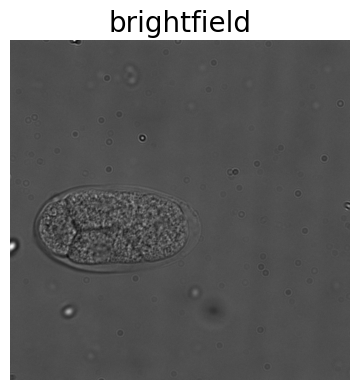

Detected file type: DeltaVision (.dv)
Image ID: 230713_Lp306_L4440_11

Processing file 230713_Lp306_L4440_11_R3D.dv with shape: (4, 51, 1024, 1024)
Loaded 4D color channel stack


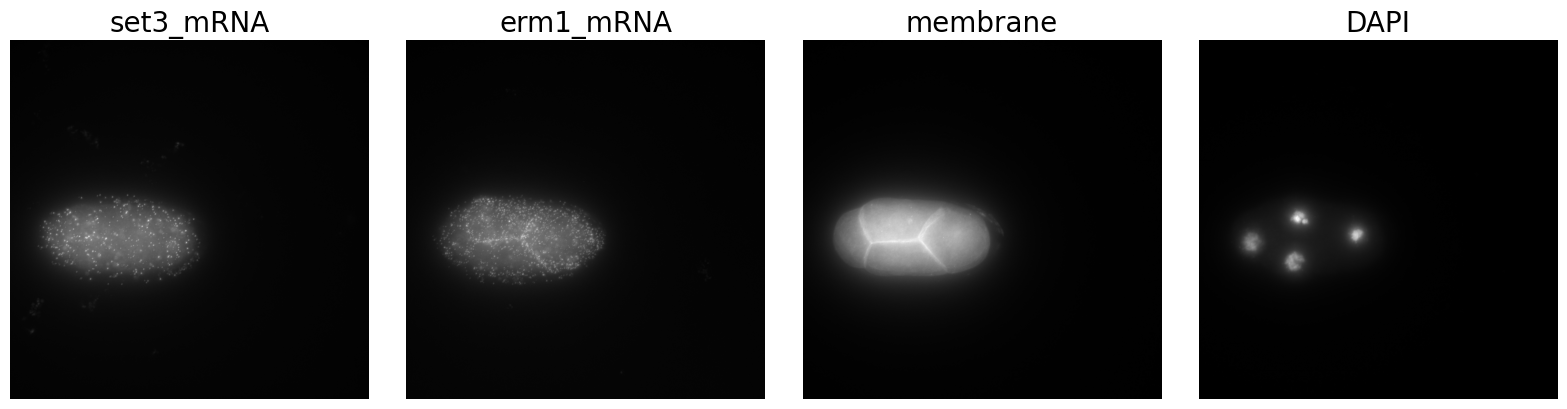

Channel 0 array shape: (51, 1024, 1024)
Channel 1 array shape: (51, 1024, 1024)


In [5]:
# Set output directory
output_directory = folder_name.parent / "output" / folder_name.name
output_directory.mkdir(parents=True, exist_ok=True)

print(f"Image folder: {folder_name}")
print(f"Output directory: {output_directory}")


# Load images using WormLib function
bf_result = None
if image_ref.exists():
    bf_result = wormlib.load_images(
        image_path=str(image_ref),
        output_directory=output_directory,
        channel_names={'brightfield': brightfield},
        slice_to_plot=12,
    )

color_result = None
if image_path.exists():
    color_result = wormlib.load_images(
        image_path=str(image_path),
        output_directory=output_directory,
        channel_names=channel_names,
        channel_indices=channel_indices,
        slice_to_plot=12,
    )

# Unpack results
bf = bf_result['bf'] if bf_result else None
image_name = bf_result['image_name'] if bf_result else (color_result['image_name'] if color_result else "unknown")

image_ch0 = color_result.get('image_Cy5') if color_result else None
image_ch1 = color_result.get('image_mCherry') if color_result else None
image_ch2 = color_result.get('image_FITC') if color_result else None
image_nuclei = color_result.get('image_nuclei') if color_result else None

ch0_array = color_result.get('Cy5_array') if color_result else None
ch1_array = color_result.get('mCherry_array') if color_result else None

grid_width = color_result.get('grid_width', 80) if color_result else 80
grid_height = color_result.get('grid_height', 80) if color_result else 80

# print(f"Image name: {image_name}")
# print(f"Brightfield shape: {bf.shape if bf is not None else 'None'}")
print(f"Channel 0 array shape: {ch0_array.shape if ch0_array is not None else 'None'}")
print(f"Channel 1 array shape: {ch1_array.shape if ch1_array is not None else 'None'}")

## 3. Segmentation

In [ ]:
# Cell segmentation
masks_cytosol = None
masks_nuclei = None
features_df = None
cell_stage = "no-nuclei"
fallback_to_embryo = False

if run_cell_segmentation and bf is not None and image_ch2 is not None:
    print("Running cell segmentation...")
    image_cytosol = bf
    second_image_cytosol = image_nuclei  # DAPI channel
    
    masks_cytosol, masks_nuclei, _, _ = wormlib.segmentation(
        image_cytosol, 
        image_nuclei,  # nuclei image
        second_image_cytosol,
        output_directory=output_directory,
    )
    
    # Determine cell stage
    cell_stage, nuclei_sizes, masks_filtered = wormlib.get_cell_stage_and_size_filtered(
        masks_nuclei, voxel_size
    )
    print(f"Cell stage: {cell_stage}")
elif run_cell_segmentation and bf is None and image_ch2 is not None:
    print("Running nuclear-only segmentation...")
    masks_nuclei = wormlib.nuclear_segmentation(image_ch2)
    masks_cytosol = masks_nuclei
    cell_stage = "nuclei-only"
    run_cell_classifier = False

Running cell segmentation...


/opt/anaconda3/envs/wormlib/lib/python3.11/site-packages/cellpose/resnet_torch.py:275: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filename, map_lo

In [ ]:
# Cell classification
if run_cell_classifier and masks_cytosol is not None:
    models_dir = main_dir / "models"
    model_2cell_path = models_dir / "2-cell_classification_RFmodel.joblib"
    model_4cell_path = models_dir / "4-cell_classification_RFmodel.joblib"
    
    if cell_stage == "2-cell" and model_2cell_path.exists():
        print("Running 2-cell classifier...")
        features_df = wormlib.classify_2cell(
            masks_cytosol=masks_cytosol, 
            bf=bf,
            image_name=image_name, 
            output_directory=output_directory,
            model_path=str(model_2cell_path), 
            verbose=True,
        )
    elif cell_stage == "4-cell" and model_4cell_path.exists():
        print("Running 4-cell classifier...")
        features_df = wormlib.classify_4cell(
            masks_cytosol=masks_cytosol, 
            bf=bf,
            image_name=image_name, 
            output_directory=output_directory,
            model_path=str(model_4cell_path), 
            verbose=True,
        )
    else:
        print(f"Classifier not available for stage '{cell_stage}'")
        run_cell_classifier = False

## 4. Spot Detection

In [ ]:
# Spot detection
list_spots_ch0, list_spots_ch1 = [], []
spots_post_clustering_ch0, spots_post_clustering_ch1 = None, None

if run_spot_detection and masks_cytosol is not None:
    if ch0 is not None and ch0_array is not None:
        print(f"Detecting spots in {ch0}...")
        spots_post_clustering_ch0, clusters_ch0, list_spots_ch0, _ = wormlib.spot_detection(
            ch0_array, 
            voxel_size, 
            spot_radius_ch0, 
            masks_cytosol,
            image_name=image_name, 
            rna_channel=ch0,
            detection_color="red", 
            output_directory=str(output_directory),
        )
        print(f"Found {len(list_spots_ch0)} cells with spots in {ch0}")
    
    if ch1 is not None and ch1_array is not None:
        print(f"Detecting spots in {ch1}...")
        spots_post_clustering_ch1, clusters_ch1, list_spots_ch1, _ = wormlib.spot_detection(
            ch1_array, 
            voxel_size, 
            spot_radius_ch1, 
            masks_cytosol,
            image_name=image_name, 
            rna_channel=ch1,
            detection_color="blue", 
            output_directory=str(output_directory),
        )
        print(f"Found {len(list_spots_ch1)} cells with spots in {ch1}")

## 5. Save mRNA Counts

In [ ]:
# Save quantification results
sum_spots_ch0 = sum(list_spots_ch0) if list_spots_ch0 else None
sum_spots_ch1 = sum(list_spots_ch1) if list_spots_ch1 else None

if any(x is not None for x in [sum_spots_ch0, sum_spots_ch1]):
    # Wide format (total counts)
    data_wide = {'Image ID': image_name}
    if ch0 is not None and sum_spots_ch0 is not None:
        data_wide[f'{ch0} total molecules'] = sum_spots_ch0
    if ch1 is not None and sum_spots_ch1 is not None:
        data_wide[f'{ch1} total molecules'] = sum_spots_ch1
    
    df_quantification = pd.DataFrame([data_wide])
    quantification_output = os.path.join(output_directory, f'total_mRNA_counts_{image_name}.csv')
    df_quantification.to_csv(quantification_output, index=False)
    print("\nTotal mRNA counts:")
    print(df_quantification)
    
    # Long format (per-cell counts)
    num_regions = max(len(list_spots_ch0), len(list_spots_ch1)) if (list_spots_ch0 or list_spots_ch1) else 0
    if num_regions > 0:
        rows_long = []
        for i in range(num_regions):
            row = {'Image ID': image_name, 'region_id': i + 1}
            if ch0 is not None and list_spots_ch0:
                row[ch0] = list_spots_ch0[i] if i < len(list_spots_ch0) else 0
            if ch1 is not None and list_spots_ch1:
                row[ch1] = list_spots_ch1[i] if i < len(list_spots_ch1) else 0
            if features_df is not None:
                row['label'] = features_df.at[i, "highest_confidence_label"]
                row['confidence'] = round(features_df.at[i, "prediction_confidence"], 3)
            rows_long.append(row)
        
        df_long = pd.DataFrame(rows_long)
        output_prefix = "per_cell" if features_df is not None else "per_region"
        long_output = os.path.join(output_directory, f'{output_prefix}_mRNA_counts_{image_name}.csv')
        df_long.to_csv(long_output, index=False)
        print(f"\nPer-cell mRNA counts:")
        print(df_long)

## 6. Spatial Analysis of mRNA

In [ ]:
# RNA heatmaps
if run_mRNA_heatmaps and masks_cytosol is not None:
    print("Generating heatmaps...")
    
    if spots_post_clustering_ch0 is not None and image_ch0 is not None:
        print(f"Heatmap for {ch0}")
        wormlib.create_local_heatmap(
            spots_post_clustering_ch0, 
            image_ch0, 
            ch0, 
            masks_cytosol, 
            grid_width, 
            grid_height, 
            image_name, 
            str(output_directory)
        )
    
    if spots_post_clustering_ch1 is not None and image_ch1 is not None:
        print(f"Heatmap for {ch1}")
        wormlib.create_local_heatmap(
            spots_post_clustering_ch1, 
            image_ch1, 
            ch1, 
            masks_cytosol, 
            grid_width, 
            grid_height, 
            image_name, 
            str(output_directory)
        )

In [ ]:
# Line scan analysis
if run_line_scan_analysis and masks_cytosol is not None:
    print("Performing line scan analysis...")
    
    if image_ch0 is not None:
        print(f"Line scan for {ch0}")
        wormlib.line_scan(
            image=image_ch0, 
            masks_cytosol=masks_cytosol, 
            colormap='PiYG',
            mRNA_name=ch0, 
            image_name=image_name, 
            output_directory=str(output_directory),
            run_cell_classifier=run_cell_classifier, 
            features_df=features_df, 
            df_long=locals().get('df_long', None),
        )
    
    if image_ch1 is not None:
        print(f"Line scan for {ch1}")
        wormlib.line_scan(
            image=image_ch1, 
            masks_cytosol=masks_cytosol, 
            colormap='PiYG',
            mRNA_name=ch1, 
            image_name=image_name, 
            output_directory=str(output_directory),
            run_cell_classifier=run_cell_classifier, 
            features_df=features_df, 
            df_long=locals().get('df_long', None),
        )

## 7. Export PDF Report

In [ ]:
# Generate PDF report
wormlib.generate_pdf_report(image_name, str(output_directory))

## Analysis Complete
All results have been saved to the output directory.